In [1]:
import os
print(os.listdir("../data"))

['africa_benchmark.csv', 'crypto_market_data.csv', 'google_trends_demand_index.csv', 'google_trends_raw.csv', 'google_trends_summary.csv', 'kenya_infra_summary.csv', 'kenya_payments.csv', 'master_dataset.csv']


In [2]:
import pandas as pd

# Check exact column names in each file
files = {
    "crypto":    "crypto_market_data.csv",
    "demand":    "google_trends_demand_index.csv",
    "benchmark": "africa_benchmark.csv",
    "kenya":     "kenya_infra_summary.csv"
}

for name, file in files.items():
    df = pd.read_csv(f"../data/{file}")
    print(f"\n{name} — {df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  Sample date col: {df.iloc[0,0]}")


crypto — (365, 25)
  Columns: ['date', 'bitcoin_price_usd', 'bitcoin_volume_usd', 'ethereum_price_usd', 'ethereum_volume_usd', 'tether_price_usd', 'tether_volume_usd', 'market_liquidity', 'liquidity_index', 'btc_return', 'eth_return', 'btc_signal', 'eth_signal', 'CMI', 'CMI_index', 'CMI_raw', 'btc_volatility', 'eth_volatility', 'liquidity_stress', 'btc_vol_norm', 'eth_vol_norm', 'liq_stress_norm', 'MSI', 'MSI_raw', 'MSI_index']
  Sample date col: 2025-06-21

demand — (212, 7)
  Columns: ['week', 'country', 'interest_USDT', 'interest_bitcoin', 'interest_crypto', 'demand_index_raw', 'demand_index']
  Sample date col: 2025-12-28

benchmark — (4, 12)
  Columns: ['country', 'country_code', 'mobile_money_penetration_pct', 'banked_population_pct', 'unbanked_population_millions', 'internet_penetration_pct', 'smartphone_penetration_pct', 'crypto_regulation_score', 'gdp_per_capita_usd', 'inflation_rate_2024_pct', 'payment_readiness_raw', 'payment_readiness_score']
  Sample date col: Kenya

keny

In [3]:
import pandas as pd
import numpy as np
import os

OUTPUT_DIR = "../data"

# Load all sources with exact column names confirmed
df_crypto    = pd.read_csv(f"{OUTPUT_DIR}/crypto_market_data.csv",
                           parse_dates=["date"])
df_demand    = pd.read_csv(f"{OUTPUT_DIR}/google_trends_demand_index.csv",
                           parse_dates=["week"])
df_benchmark = pd.read_csv(f"{OUTPUT_DIR}/africa_benchmark.csv")
df_kenya     = pd.read_csv(f"{OUTPUT_DIR}/kenya_infra_summary.csv")

print("=== DATA SOURCES LOADED ===")
print(f"  Crypto:    {df_crypto.shape}")
print(f"  Demand:    {df_demand.shape}")
print(f"  Benchmark: {df_benchmark.shape}")
print(f"  Kenya:     {df_kenya.shape}")

=== DATA SOURCES LOADED ===
  Crypto:    (365, 25)
  Demand:    (212, 7)
  Benchmark: (4, 12)
  Kenya:     (1, 6)


In [4]:
# Select only the columns we need for the master dataset
crypto_cols = [
    "date",
    "bitcoin_price_usd",
    "bitcoin_volume_usd",
    "ethereum_price_usd",
    "ethereum_volume_usd",
    "CMI_index",
    "MSI_index",
    "btc_return",
    "eth_return",
    "btc_volatility",
    "eth_volatility"
]

df_crypto_slim = df_crypto[crypto_cols].copy()

# Resample daily → weekly
df_crypto_weekly = (
    df_crypto_slim
    .set_index("date")
    .resample("W")
    .agg({
        "bitcoin_price_usd":   "last",
        "bitcoin_volume_usd":  "sum",
        "ethereum_price_usd":  "last",
        "ethereum_volume_usd": "sum",
        "CMI_index":           "last",
        "MSI_index":           "last",
        "btc_return":          "mean",
        "eth_return":          "mean",
        "btc_volatility":      "last",
        "eth_volatility":      "last"
    })
    .reset_index()
    .rename(columns={"date": "week"})
)

print(f"Crypto resampled to weekly: {df_crypto_weekly.shape}")
print(f"Date range: {df_crypto_weekly.week.min().date()} to {df_crypto_weekly.week.max().date()}")
print(df_crypto_weekly.head(3).to_string(index=False))

Crypto resampled to weekly: (53, 11)
Date range: 2025-06-22 to 2026-06-21
      week  bitcoin_price_usd  bitcoin_volume_usd  ethereum_price_usd  ethereum_volume_usd  CMI_index  MSI_index  btc_return  eth_return  btc_volatility  eth_volatility
2025-06-22      101532.568385        5.227721e+10         2270.581996         3.663843e+10  30.723694  33.623970   -0.008508   -0.028082             NaN             NaN
2025-06-29      107331.585485        2.219477e+11         2437.133002         1.240178e+11   5.758724  77.756455    0.008098    0.010683        0.017763        0.035634
2025-07-06      108217.468500        1.629828e+11         2517.379178         1.043415e+11  10.664423  57.214530    0.001289    0.005174        0.016355        0.035694


In [5]:
# Use left join — keep all demand weeks
# Crypto data fills in where dates overlap
df_master = pd.merge(
    df_demand,
    df_crypto_weekly,
    on="week",
    how="inner"
)

print(f"After merge — demand + crypto: {df_master.shape}")
print(f"Countries: {df_master.country.unique().tolist()}")
print(f"Weeks: {df_master.week.nunique()}")
print(f"Nulls after merge: {df_master.isnull().sum().sum()}")

After merge — demand + crypto: (104, 17)
Countries: ['Ghana', 'Kenya', 'Nigeria', 'South Africa']
Weeks: 26
Nulls after merge: 0


In [6]:
# Add benchmark
benchmark_cols = [
    "country",
    "mobile_money_penetration_pct",
    "banked_population_pct",
    "internet_penetration_pct",
    "smartphone_penetration_pct",
    "payment_readiness_score",
    "gdp_per_capita_usd",
    "inflation_rate_2024_pct",
    "crypto_regulation_score"
]

df_master = pd.merge(
    df_master,
    df_benchmark[benchmark_cols],
    on="country",
    how="left"
)

# Add Kenya infra — only Kenya rows will have values
# Fill other countries with 0 — they use different payment rails
kenya_cols = [
    "country",
    "avg_monthly_txn_millions",
    "avg_monthly_value_kes_bn",
    "avg_mom_growth_pct"
]

df_master = pd.merge(
    df_master,
    df_kenya[kenya_cols],
    on="country",
    how="left"
)

# Fill NaN for non-Kenya countries with 0
# Document: M-Pesa data only applicable to Kenya
mpesa_cols = ["avg_monthly_txn_millions",
              "avg_monthly_value_kes_bn",
              "avg_mom_growth_pct"]

df_master[mpesa_cols] = df_master[mpesa_cols].fillna(0)

print(f"Shape after all merges: {df_master.shape}")
print(f"Nulls: {df_master.isnull().sum().sum()}")

# Verify Kenya rows have M-Pesa data
print(f"\nKenya avg_monthly_txn_millions sample: {df_master[df_master.country=='Kenya']['avg_monthly_txn_millions'].iloc[0]}")
print(f"Nigeria avg_monthly_txn_millions (should be 0): {df_master[df_master.country=='Nigeria']['avg_monthly_txn_millions'].iloc[0]}")

Shape after all merges: (104, 28)
Nulls: 0

Kenya avg_monthly_txn_millions sample: 204.2
Nigeria avg_monthly_txn_millions (should be 0): 0.0


In [7]:
print("=== MASTER DATASET QUALITY REPORT ===")
print(f"\nShape:      {df_master.shape}")
print(f"Date range: {df_master.week.min().date()} to {df_master.week.max().date()}")
print(f"Countries:  {df_master.country.unique().tolist()}")

nulls = df_master.isnull().sum()
total_nulls = nulls.sum()
print(f"\nTotal nulls: {total_nulls}")
if total_nulls > 0:
    print("\nColumns with nulls:")
    print(nulls[nulls > 0])
else:
    print("✓ Zero nulls — clean dataset")

print(f"\nAll columns:")
for i, col in enumerate(df_master.columns, 1):
    print(f"  {i:02d}. {col}")

=== MASTER DATASET QUALITY REPORT ===

Shape:      (104, 28)
Date range: 2025-12-28 to 2026-06-21
Countries:  ['Ghana', 'Kenya', 'Nigeria', 'South Africa']

Total nulls: 0
✓ Zero nulls — clean dataset

All columns:
  01. week
  02. country
  03. interest_USDT
  04. interest_bitcoin
  05. interest_crypto
  06. demand_index_raw
  07. demand_index
  08. bitcoin_price_usd
  09. bitcoin_volume_usd
  10. ethereum_price_usd
  11. ethereum_volume_usd
  12. CMI_index
  13. MSI_index
  14. btc_return
  15. eth_return
  16. btc_volatility
  17. eth_volatility
  18. mobile_money_penetration_pct
  19. banked_population_pct
  20. internet_penetration_pct
  21. smartphone_penetration_pct
  22. payment_readiness_score
  23. gdp_per_capita_usd
  24. inflation_rate_2024_pct
  25. crypto_regulation_score
  26. avg_monthly_txn_millions
  27. avg_monthly_value_kes_bn
  28. avg_mom_growth_pct


In [8]:
master_path = f"{OUTPUT_DIR}/master_dataset.csv"
df_master.to_csv(master_path, index=False)

# Verify
df_verify = pd.read_csv(master_path)
print(f"✓ Saved: {master_path}")
print(f"  Shape:   {df_verify.shape}")
print(f"  Nulls:   {df_verify.isnull().sum().sum()}")
print(f"  Size:    {os.path.getsize(master_path)/1024:.1f} KB")

✓ Saved: ../data/master_dataset.csv
  Shape:   (104, 28)
  Nulls:   0
  Size:    30.3 KB


In [9]:
print("Crypto weekly date sample:")
print(df_crypto_weekly.week.head(5).tolist())
print(f"Crypto dtype: {df_crypto_weekly.week.dtype}")

print("\nDemand weekly date sample:")
print(df_demand.week.head(5).tolist())
print(f"Demand dtype: {df_demand.week.dtype}")

# Check overlap
crypto_weeks = set(df_crypto_weekly.week.dt.date)
demand_weeks = set(df_demand.week.dt.date)
overlap = crypto_weeks.intersection(demand_weeks)
print(f"\nCrypto weeks: {len(crypto_weeks)}")
print(f"Demand weeks: {len(demand_weeks)}")
print(f"Overlapping weeks: {len(overlap)}")
print(f"\nFirst 3 overlap dates: {sorted(overlap)[:3]}")

Crypto weekly date sample:
[Timestamp('2025-06-22 00:00:00'), Timestamp('2025-06-29 00:00:00'), Timestamp('2025-07-06 00:00:00'), Timestamp('2025-07-13 00:00:00'), Timestamp('2025-07-20 00:00:00')]
Crypto dtype: datetime64[us]

Demand weekly date sample:
[Timestamp('2025-12-28 00:00:00'), Timestamp('2025-12-28 00:00:00'), Timestamp('2025-12-28 00:00:00'), Timestamp('2025-12-28 00:00:00'), Timestamp('2026-01-04 00:00:00')]
Demand dtype: datetime64[us]

Crypto weeks: 53
Demand weeks: 53
Overlapping weeks: 26

First 3 overlap dates: [datetime.date(2025, 12, 28), datetime.date(2026, 1, 4), datetime.date(2026, 1, 11)]


## Dataset Note — Temporal Coverage

Crypto market data: June 2025 – June 2026 (CoinGecko, 365 days)
Demand signals: December 2025 – June 2026 (SerpApi, 52 weeks forward)
Master dataset overlap: 26 weeks (December 2025 – June 2026)

Next pipeline run should align both sources to the same date window
from the start. Day 7 Airflow DAG will enforce this alignment
automatically.

In [10]:
print(df_master.groupby("country")["demand_index"].mean().sort_values(ascending=False).round(2))
print(df_master.groupby("country")["CMI_index"].mean().round(2))
print(df_master.groupby("country")["payment_readiness_score"].mean().round(2))

country
South Africa    29.07
Nigeria         23.18
Ghana           17.16
Kenya           16.93
Name: demand_index, dtype: float64
country
Ghana           16.07
Kenya           16.07
Nigeria         16.07
South Africa    16.07
Name: CMI_index, dtype: float64
country
Ghana           53.9
Kenya           56.1
Nigeria         45.9
South Africa    46.0
Name: payment_readiness_score, dtype: float64


In [11]:
# Confirm what is actually in the saved CSV
df_check = pd.read_csv("../data/africa_benchmark.csv")
print(df_check[["country", "payment_readiness_score"]])

        country  payment_readiness_score
0         Kenya                     56.1
1       Nigeria                     45.9
2         Ghana                     53.9
3  South Africa                     46.0


In [12]:
# Correct payment readiness — absolute weighted composite
# No min-max normalization — scores against fixed scale
df_benchmark["payment_readiness_score"] = (
    df_benchmark["mobile_money_penetration_pct"] * 0.50 +
    df_benchmark["internet_penetration_pct"]     * 0.25 +
    df_benchmark["smartphone_penetration_pct"]   * 0.15 +
    df_benchmark["banked_population_pct"]        * 0.10
).round(1)

print("=== CORRECTED PAYMENT READINESS SCORES ===")
print(df_benchmark[["country",
                     "mobile_money_penetration_pct",
                     "internet_penetration_pct",
                     "smartphone_penetration_pct",
                     "banked_population_pct",
                     "payment_readiness_score"
                    ]].sort_values("payment_readiness_score",
                                   ascending=False).to_string(index=False))

# Overwrite the CSV with corrected scores
df_benchmark.to_csv("../data/africa_benchmark.csv", index=False)
print("\nSaved: africa_benchmark.csv — corrected scores")

=== CORRECTED PAYMENT READINESS SCORES ===
     country  mobile_money_penetration_pct  internet_penetration_pct  smartphone_penetration_pct  banked_population_pct  payment_readiness_score
       Kenya                          73.2                      29.1                        28.4                   79.4                     56.1
       Ghana                          57.8                      53.6                        38.7                   58.1                     53.9
South Africa                          11.3                      72.3                        91.2                   85.7                     46.0
     Nigeria                          42.6                      55.4                        41.2                   45.3                     45.9

Saved: africa_benchmark.csv — corrected scores


Matplotlib is building the font cache; this may take a moment.


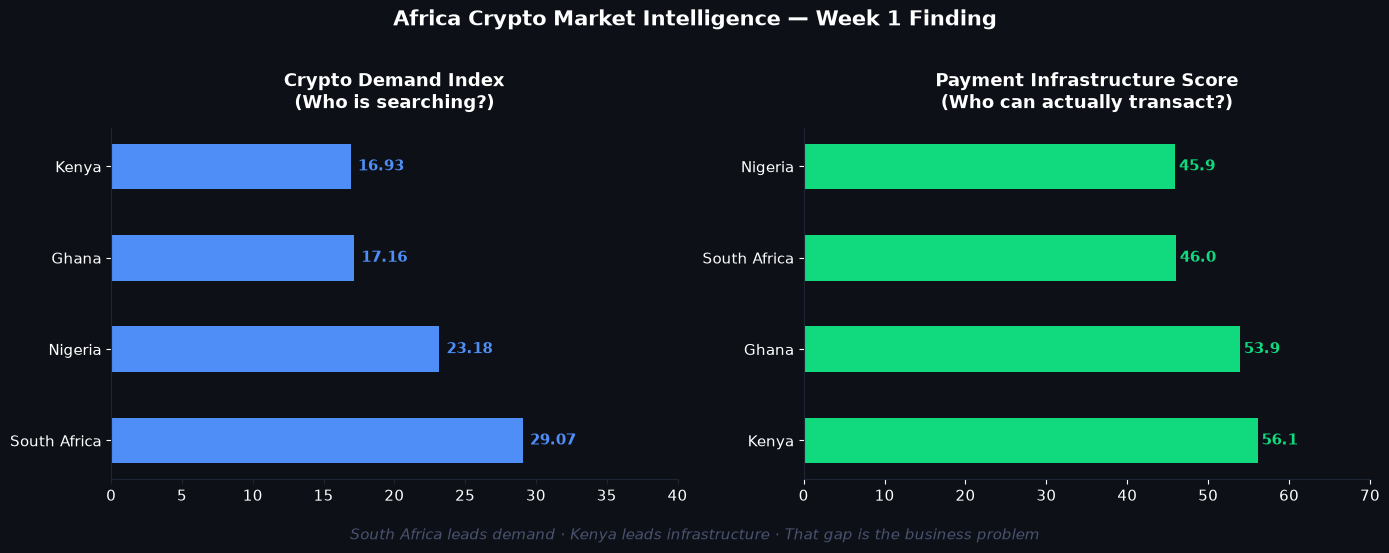

Saved: ../visuals/week1_key_finding.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0D1117")

countries = ["South Africa", "Nigeria", "Ghana", "Kenya"]
demand    = [29.07, 23.18, 17.16, 16.93]
readiness = [46.0, 45.9, 53.9, 56.1]
colors_d  = ["#4f8ef7", "#4f8ef7", "#4f8ef7", "#4f8ef7"]
colors_r  = ["#10d97e", "#10d97e", "#10d97e", "#10d97e"]

# ── Chart 1: Demand Index ──
bars1 = ax1.barh(countries, demand, color=colors_d, height=0.5)
ax1.set_facecolor("#0D1117")
ax1.set_xlim(0, 40)
ax1.set_title("Crypto Demand Index\n(Who is searching?)",
              color="white", fontsize=13, fontweight="bold", pad=14)
ax1.tick_params(colors="white", labelsize=11)
ax1.xaxis.label.set_color("white")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color("#1e2535")
ax1.spines["bottom"].set_color("#1e2535")
ax1.xaxis.set_tick_params(color="#1e2535")
for bar, val in zip(bars1, demand):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val}", va="center", color="#4f8ef7",
             fontsize=11, fontweight="bold")

# ── Chart 2: Payment Readiness ──
# Sort by readiness descending for this chart
countries_r = ["Kenya", "Ghana", "South Africa", "Nigeria"]
readiness_r = [56.1, 53.9, 46.0, 45.9]

bars2 = ax2.barh(countries_r, readiness_r, color=colors_r, height=0.5)
ax2.set_facecolor("#0D1117")
ax2.set_xlim(0, 70)
ax2.set_title("Payment Infrastructure Score\n(Who can actually transact?)",
              color="white", fontsize=13, fontweight="bold", pad=14)
ax2.tick_params(colors="white", labelsize=11)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_color("#1e2535")
ax2.spines["bottom"].set_color("#1e2535")
for bar, val in zip(bars2, readiness_r):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val}", va="center", color="#10d97e",
             fontsize=11, fontweight="bold")

# ── Footer ──
fig.text(0.5, -0.04,
         "South Africa leads demand · Kenya leads infrastructure · That gap is the business problem",
         ha="center", color="#4a5270", fontsize=11, style="italic")

plt.suptitle("Africa Crypto Market Intelligence — Week 1 Finding",
             color="white", fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("../visuals/week1_key_finding.png",
            dpi=150, bbox_inches="tight",
            facecolor="#0D1117", edgecolor="none")
plt.show()
print("Saved: ../visuals/week1_key_finding.png")